Training data size: 7920
Testing data size: 1980


  0%|          | 0/15 [00:00<?, ?it/s]

Epoch [1/15], Train Loss: 3.1872, Test Loss: 1.4358, Train Accuracy: 23.43%, Test Accuracy: 56.82%
Test Accuracy: 56.82%
Epoch [2/15], Train Loss: 1.0738, Test Loss: 0.9551, Train Accuracy: 68.31%, Test Accuracy: 72.37%
Test Accuracy: 72.37%
Epoch [3/15], Train Loss: 0.6929, Test Loss: 0.6650, Train Accuracy: 78.99%, Test Accuracy: 81.01%
Test Accuracy: 81.01%
Epoch [4/15], Train Loss: 0.4814, Test Loss: 0.5139, Train Accuracy: 85.21%, Test Accuracy: 84.09%
Test Accuracy: 84.09%
Epoch [5/15], Train Loss: 0.3500, Test Loss: 0.5340, Train Accuracy: 89.29%, Test Accuracy: 83.69%
Test Accuracy: 83.69%
Epoch [6/15], Train Loss: 0.2710, Test Loss: 0.4758, Train Accuracy: 91.46%, Test Accuracy: 86.11%
Test Accuracy: 86.11%
Epoch [7/15], Train Loss: 0.2106, Test Loss: 0.4483, Train Accuracy: 93.09%, Test Accuracy: 87.32%
Test Accuracy: 87.32%
Epoch [8/15], Train Loss: 0.1615, Test Loss: 0.4059, Train Accuracy: 94.87%, Test Accuracy: 88.84%
Test Accuracy: 88.84%
Epoch [9/15], Train Loss: 0.1182

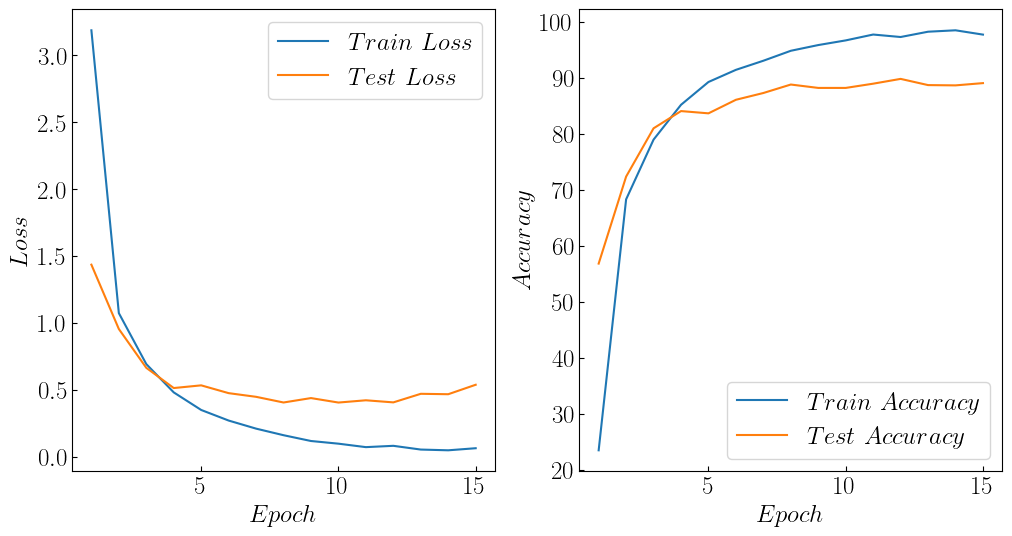

In [8]:
import os
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from tqdm.auto import tqdm


class QuickDrawDataset(Dataset): 
    def __init__(self, root_dir, transforms=None): 
        """ root_dir: path to the folder containing subfolders of images (each representing a class)
        transform: transformation to apply on images (e.g., normalization)"""

        self.root_dir = root_dir 
        self.transform = transforms 
        self.classes = os.listdir(root_dir) 
        self.images_paths = [] 

        """ Iterate over all the subfolders (classes) and collect image paths and labels"""
        for label in self.classes: 
            class_folder = os.path.join(root_dir, label) 
            if os.path.isdir(class_folder): 
                for img_name in os.listdir(class_folder): 
                    img_path = os.path.join(class_folder, img_name) 
                    self.images_paths.append((img_path, label))
        
    def __len__(self): 
            return len(self.images_paths) 
        
    def __getitem__(self, idx):
        img_path, label = self.images_paths[idx]
        img = Image.open(img_path)  
        
        if self.transform:
            img = self.transform(img) 
        return img, self.classes.index(label)

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  
    transforms.Resize((28, 28)), 
    transforms.ToTensor(),  
    transforms.Normalize((0.5,), (0.5,)),
])

data_dir = "data" 
full_dataset = QuickDrawDataset(root_dir=data_dir, transforms=transform) 
train_size = int(0.8 * len(full_dataset)) 
test_size = len(full_dataset) - train_size 

train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Training data size: {len(train_dataset)}")
print(f"Testing data size: {len(test_dataset)}")


class CNNModel(nn.Module): 
    def __init__(self): 
        super(CNNModel, self).__init__() 

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1) 
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) 
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) 

        self.pool = nn.MaxPool2d(2, 2) 

        self.fc1 = nn.Linear(128 * 3 * 3, 512) 
        self.fc2 = nn.Linear(512, 100) 

    def forward(self, x): 
        x = self.pool(F.relu(self.conv1(x))) 
        x = self.pool(F.relu(self.conv2(x))) 
        x = self.pool(F.relu(self.conv3(x))) 

        x = x.view(-1, 128 * 3 * 3) 
        x = F.relu(self.fc1(x)) 

        x = self.fc2(x) 

        return x 
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNModel().to(device)

criterion = nn.CrossEntropyLoss()  
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 15

train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in tqdm(range(num_epochs)):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(100 * correct_train / total_train)
    
    model.eval()
    running_loss = 0.0
    correct_test = 0
    total_test = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
    
    test_losses.append(running_loss / len(test_loader))
    test_accuracies.append(100 * correct_test / total_test)
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_losses[-1]:.4f}, Test Loss: {test_losses[-1]:.4f}, "
          f"Train Accuracy: {train_accuracies[-1]:.2f}%, Test Accuracy: {test_accuracies[-1]:.2f}%")
    test_acc = 100 * correct_test / total_test
    print(f"Test Accuracy: {test_acc:.2f}%")

torch.save(model.state_dict(), "model.pth")
plt.rc("text", usetex = True)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label=r'$Train$ $Loss$')
plt.plot(range(1, num_epochs+1), test_losses, label=r'$Test$ $Loss$')
plt.xlabel(r'$Epoch$', fontsize = 18)
plt.ylabel(r'$Loss$', fontsize = 18)
plt.tick_params(direction = "in", labelsize = 18)
plt.legend(fontsize = 18)

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, label=r'$Train$ $Accuracy$')
plt.plot(range(1, num_epochs+1), test_accuracies, label=r'$Test$ $Accuracy$')
plt.xlabel(r'$Epoch$', fontsize = 18)
plt.ylabel(r'$Accuracy$', fontsize = 18)
plt.tick_params(direction = "in", labelsize = 18)
plt.legend(fontsize = 18)


desktop_path = os.path.join(os.path.expanduser("~"), "Desktop")  
if not os.path.exists(desktop_path):
    desktop_path = os.path.join("C:\\", "Users", "YourName", "Desktop")  


plt.savefig(os.path.join(desktop_path, "train_test_loss.png"))
plt.savefig(os.path.join(desktop_path, "train_test_accuracy.png"))
plt.show()

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

eval_model = CNNModel().to(device)
eval_model.load_state_dict(torch.load("model.pth", map_location=device))
eval_model.eval()

correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = eval_model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

final_test_acc = 100 * correct / total
print(f"Final Test Accuracy (from model.pth): {final_test_acc:.2f}%")


Final Test Accuracy (from model.pth): 89.09%


In [10]:
import os
import matplotlib.pyplot as plt

# Assuming these lists (train_losses, test_losses, etc.) are already populated
# Example of the loop with your previous model training (not included in this code block)

# 1. Save Training vs Test Loss plot separately
plt.figure(figsize=(12, 6))
plt.plot(range(1, num_epochs+1), train_losses, label=r'$Train$ $Loss$')
plt.plot(range(1, num_epochs+1), test_losses, label=r'$Test$ $Loss$')
plt.xlabel(r'$Epoch$', fontsize=18)
plt.ylabel(r'$Loss$', fontsize=18)
plt.tick_params(direction="in", labelsize=18)
plt.legend(fontsize=18)

# Save the loss plot to desktop
desktop_path = os.path.join(os.path.expanduser("~"), "Desktop")  
if not os.path.exists(desktop_path):
    desktop_path = os.path.join("C:\\", "Users", "YourName", "Desktop")  
plt.savefig(os.path.join(desktop_path, "train_test_loss.png"))
plt.close()  # Close the current figure to avoid overlap with the next plot

# 2. Save Training vs Test Accuracy plot separately
plt.figure(figsize=(12, 6))
plt.plot(range(1, num_epochs+1), train_accuracies, label=r'$Train$ $Accuracy$')
plt.plot(range(1, num_epochs+1), test_accuracies, label=r'$Test$ $Accuracy$')
plt.xlabel(r'$Epoch$', fontsize=18)
plt.ylabel(r'$Accuracy$', fontsize=18)
plt.tick_params(direction="in", labelsize=18)
plt.legend(fontsize=18)

# Save the accuracy plot to desktop
plt.savefig(os.path.join(desktop_path, "train_test_accuracy.png"))
plt.close()  # Close the current figure to prevent overlap if more plots are generated

# Optionally, display the plots if you also want to view them
plt.show()


$Apply$ $on$ $the$ $test$ $data$ 

In [11]:
import os
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.nn.functional as F


# Dataset
class QuickDrawDataset(Dataset):
    def __init__(self, root_dir, transforms=None):
        self.root_dir = root_dir
        self.transform = transforms

        # IMPORTANT: keep class order consistent
        self.classes = sorted(os.listdir(root_dir))
        self.images_paths = []

        for label in self.classes:
            class_folder = os.path.join(root_dir, label)
            if os.path.isdir(class_folder):
                for img_name in os.listdir(class_folder):
                    img_path = os.path.join(class_folder, img_name)
                    self.images_paths.append((img_path, label))

    def __len__(self):
        return len(self.images_paths)

    def __getitem__(self, idx):
        img_path, label = self.images_paths[idx]
        img = Image.open(img_path)

        if self.transform:
            img = self.transform(img)

        return img, self.classes.index(label)

# Transforms (same as training)
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


# Load NEW dataset
data_dir = "remaining_images"
test_dataset = QuickDrawDataset(root_dir=data_dir, transforms=transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print(f"Testing data size: {len(test_dataset)}")
print("Class order:", test_dataset.classes)

# Model (must match training)
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 3 * 3, 512)
        self.fc2 = nn.Linear(512, 100)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 128 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# Load trained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNModel().to(device)
model.load_state_dict(torch.load("model.pth", map_location=device))
model.eval()

# Evaluation
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"\nAccuracy on new dataset: {accuracy:.2f}%")

Testing data size: 100
Class order: ['ambulance', 'angel', 'apple', 'bandage', 'baseball', 'bee', 'binoculars', 'bird', 'book', 'bracelet', 'bulldozer', 'butterfly', 'cactus', 'camel', 'candle', 'car', 'clock', 'cloud', 'coffee cup', 'computer', 'crab', 'crown', 'cruise ship', 'cup', 'diamond', 'drill', 'envelope', 'eye', 'eyeglasses', 'face', 'fence', 'fire hydrant', 'fish', 'flip flops', 'fork', 'golf club', 'guitar', 'hamburger', 'hand', 'harp', 'hat', 'helicopter', 'hexagon', 'hourglass', 'house', 'hurricane', 'ice cream', 'key', 'ladder', 'light bulb', 'lighter', 'lightning', 'lipstick', 'mailbox', 'microphone', 'microwave', 'moon', 'mouth', 'onion', 'paintbrush', 'palm tree', 'piano', 'pickup truck', 'pig', 'pizza', 'radio', 'rainbow', 'rifle', 'sailboat', 'sheep', 'shovel', 'skull', 'snail', 'snowflake', 'snowman', 'sock', 'spoon', 'spreadsheet', 'squirrel', 'stethoscope', 'submarine', 'swan', 'sword', 'syringe', 'table', 'teddy-bear', 'telephone', 'television', 'toothbrush', 't

Plotting

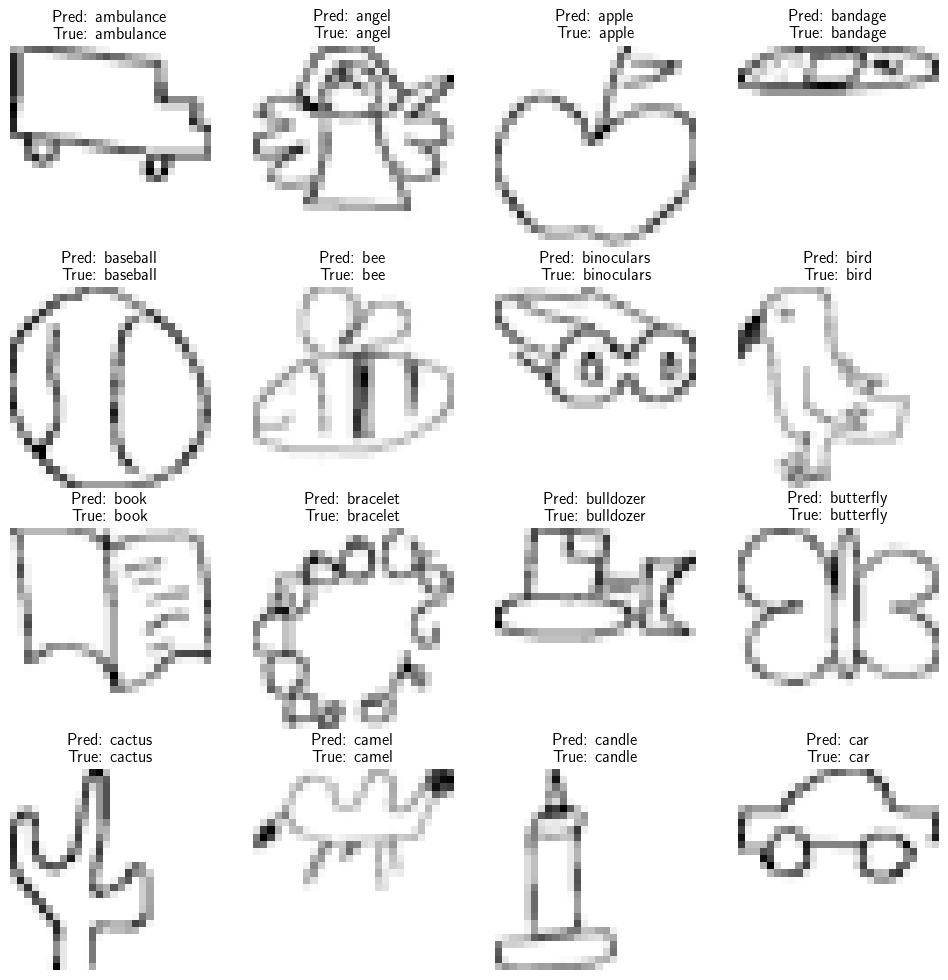

In [12]:
import matplotlib.pyplot as plt

# Get one batch
images, labels = next(iter(test_loader))

# Move to CPU and convert to numpy
images = images.cpu().numpy()
labels = labels.cpu().numpy()

# Make predictions
model.eval()
with torch.no_grad():
    outputs = model(torch.tensor(images).to(device))
    _, preds = torch.max(outputs, 1)
    preds = preds.cpu().numpy()

# Plot first 16 images
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    img = images[i].squeeze()  # remove channel dimension
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Pred: {test_dataset.classes[preds[i]]}\nTrue: {test_dataset.classes[labels[i]]}")
    ax.axis('off')
plt.show()
